<a href="https://colab.research.google.com/github/edik06031-rgb/melbourne-housing-DTA/blob/main/notebooks/melbourne_housing_snapshot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Snapshot

In [3]:
import numpy as np                                                               # NumPy — робота з масивами та математикою
import pandas as pd                                                              # Pandas — робота з таблицями
import matplotlib.pyplot as plt                                                  # Matplotlib — побудова графіків

from sklearn.model_selection import train_test_split                             # Розділяє дані на:навчальну вибірку (train), тестову вибірку (test)
from sklearn.compose import ColumnTransformer                                    # Дозволяє по-різному обробляти різні типи ознак.
from sklearn.pipeline import Pipeline                                            # Автоматично виконує всі кроки один за одним.
from sklearn.impute import SimpleImputer                                         # Заповнює пропущені значення (NaN).
from sklearn.preprocessing import OneHotEncoder                                  # Перетворює текст у числа.
from sklearn.dummy import DummyRegressor                                         # Найпростіша "дурна" модель.Вона нічого не вчить.
from sklearn.linear_model import LinearRegression                                # Будує лінійну залежність між ознаками та цільовою змінною.
from sklearn.ensemble import RandomForestRegressor                               # Одна з моделей регресії.Складається з багатьох дерев рішень.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score    # метрики оцінки.Потрібні для перевірки якості моделі.

RANDOM_STATE = 42                                                                # Фіксує випадковість.

In [6]:
#КРОК_1.ЗАВАНТАЖЕННЯ
# У Colab: замінити шлях на RAW-посилання з GitHub
RAW_URL = "https://raw.githubusercontent.com/edik06031-rgb/melbourne-housing-DTA/refs/heads/main/DATA/melb_data.csv"
df = pd.read_csv(RAW_URL)
#df = pd.read_csv("melb_data.csv")   # локальний запуск
print("Розмір:", df.shape)
print(df.head())

Розмір: (13580, 21)
       Suburb           Address  Rooms Type      Price Method SellerG  \
0  Abbotsford      85 Turner St      2    h  1480000.0      S  Biggin   
1  Abbotsford   25 Bloomburg St      2    h  1035000.0      S  Biggin   
2  Abbotsford      5 Charles St      3    h  1465000.0     SP  Biggin   
3  Abbotsford  40 Federation La      3    h   850000.0     PI  Biggin   
4  Abbotsford       55a Park St      4    h  1600000.0     VB  Nelson   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
1  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
2  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   
3  4/03/2017       2.5    3067.0  ...       2.0  1.0      94.0           NaN   
4  4/06/2016       2.5    3067.0  ...       1.0  2.0     120.0         142.0   

   YearBuilt  CouncilArea Lattitude  Longtitude             

In [8]:
# КРОК 2. ПЕРШИЙ ОГЛЯД

info = pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "пропусків_%": (df.isna().mean() * 100).round(1),
})
print(info.sort_values("пропусків_%", ascending=False))
print(df.describe())

                   тип  пропусків_%
BuildingArea   float64         47.5
YearBuilt      float64         39.6
CouncilArea     object         10.1
Car            float64          0.5
Suburb          object          0.0
Price          float64          0.0
Type            object          0.0
Rooms            int64          0.0
Address         object          0.0
Distance       float64          0.0
Method          object          0.0
Date            object          0.0
SellerG         object          0.0
Bathroom       float64          0.0
Bedroom2       float64          0.0
Postcode       float64          0.0
Landsize       float64          0.0
Lattitude      float64          0.0
Longtitude     float64          0.0
Regionname      object          0.0
Propertycount  float64          0.0
              Rooms         Price      Distance      Postcode      Bedroom2  \
count  13580.000000  1.358000e+04  13580.000000  13580.000000  13580.000000   
mean       2.937997  1.075684e+06     10.137776   

# Спостереження:
#  - BuildingArea: 47.5% пропусків, YearBuilt: 39.6%
#  - YearBuilt min = 1196 → явна помилка
#  - Landsize/BuildingArea min = 0 → нуль = "немає даних"
#  - Bedroom2 майже дублює Rooms (r = 0.94)
#  - Немає стовпця-індексу

In [9]:
# КРОК 3. ОЧИЩЕННЯ

clean = df.copy()

clean["Date"] = pd.to_datetime(clean["Date"], dayfirst=True)

for col in ["Landsize", "BuildingArea"]:
    clean.loc[clean[col] == 0, col] = np.nan

clean.loc[clean["YearBuilt"] < 1800, "YearBuilt"] = np.nan

print("Дублікатів:", clean.duplicated().sum())

Дублікатів: 0


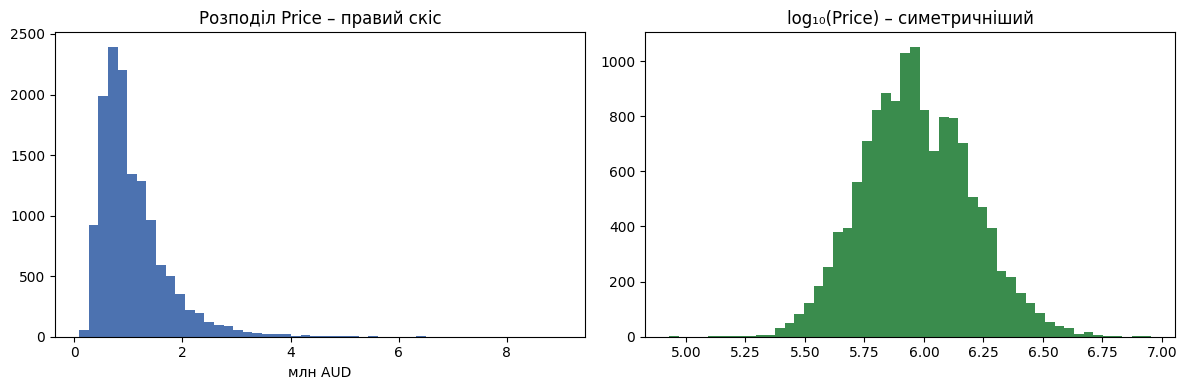

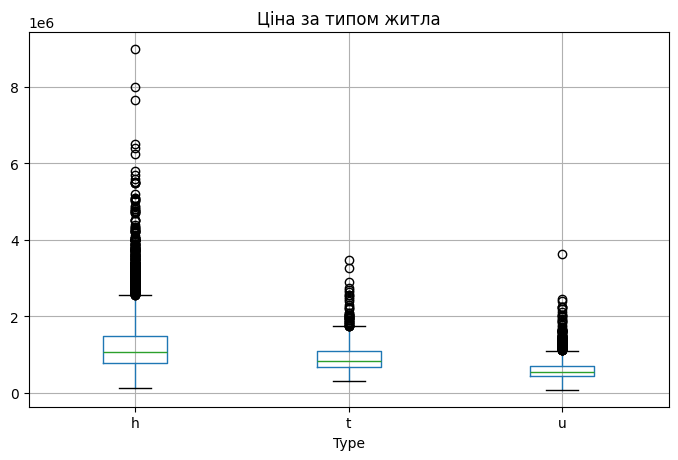

Rooms            0.497
Bedroom2         0.476
Bathroom         0.467
YearBuilt       -0.332
Car              0.239
Lattitude       -0.213
Longtitude       0.204
Distance        -0.163
Postcode         0.108
BuildingArea     0.092
Propertycount   -0.042
Landsize         0.023
Name: Price, dtype: float64
Rooms–Bedroom2: 0.944


In [16]:
# КРОК 4. EDA
# Розподіл ціни
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(clean["Price"] / 1e6, bins=50, color="#4C72B0")
axes[0].set_title("Розподіл Price – правий скіс")
axes[0].set_xlabel("млн AUD")
axes[1].hist(np.log10(clean["Price"]), bins=50, color="#3A8C4D")
axes[1].set_title("log₁₀(Price) – симетричніший")
plt.tight_layout(); plt.show()

# Boxplot за типом
clean.boxplot(column="Price", by="Type", figsize=(8, 5))
plt.title("Ціна за типом житла")
plt.suptitle("")
plt.show()

# Кореляція числових ознак із ціною
num = clean.select_dtypes("number")
cor_price = num.corr()["Price"].drop("Price")
print(cor_price.sort_values(key=abs, ascending=False).round(3))
# Rooms (0.50) і Bathroom (0.47) – найбільша кореляція
# Distance (-0.16) – слабко від'ємна (далі → дешевше)
# Landsize (0.02) – майже немає лінійного зв'язку

# Пошук дублікатів ознак
cm = num.corr().abs()
print("Rooms–Bedroom2:", cm.loc["Rooms", "Bedroom2"].round(3))  # → 0.944 ✗ дублі

In [11]:
# КРОК 5. НОВІ ОЗНАКИ
# ----------------------------------------------------------
fe = clean.copy()

fe["sale_year"]  = fe["Date"].dt.year
fe["sale_month"] = fe["Date"].dt.month
fe["age"] = fe["sale_year"] - fe["YearBuilt"]   # вік будинку

fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
fe["has_yearbuilt"]    = fe["YearBuilt"].notna().astype(int)

suburb_freq = fe["Suburb"].value_counts()
fe["suburb_freq"] = fe["Suburb"].map(suburb_freq)  # кодування через частоту

# Видаляємо: дублі, надто розріджені, безглузді для моделі
fe = fe.drop(columns=["Suburb", "Address", "Date", "SellerG", "Bedroom2", "Postcode"])

In [13]:
# КРОК 6. ПІДГОТОВКА ДО МОДЕЛЮВАННЯ

fe = fe.dropna(subset=["Price"])   # 0 пропусків у цілі

y = fe["Price"]
X = fe.drop(columns=["Price"])

cat_cols = ["Type", "Method", "CouncilArea", "Regionname"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (10864, 20), Test: (2716, 20)



Базова лінія (середнє):
  MAE  =      461,258 AUD
  RMSE =      630,259 AUD
  R²   = -0.000

Лінійна регресія:
  MAE  =      256,183 AUD
  RMSE =      372,747 AUD
  R²   = 0.650

Випадковий ліс:
  MAE  =      163,960 AUD
  RMSE =      272,056 AUD
  R²   = 0.814

Прогноз:        2,193,645 AUD
Справжня:       2,600,000 AUD
Похибка:          406,355 AUD

Топ-10 важливих ознак:
Regionname_Southern Metropolitan    0.2093
Rooms                               0.1779
Distance                            0.1389
Type_u                              0.0857
Landsize                            0.0786
Longtitude                          0.0541
BuildingArea                        0.0464
Lattitude                           0.0444
Bathroom                            0.0305
Propertycount                       0.0181
dtype: float64


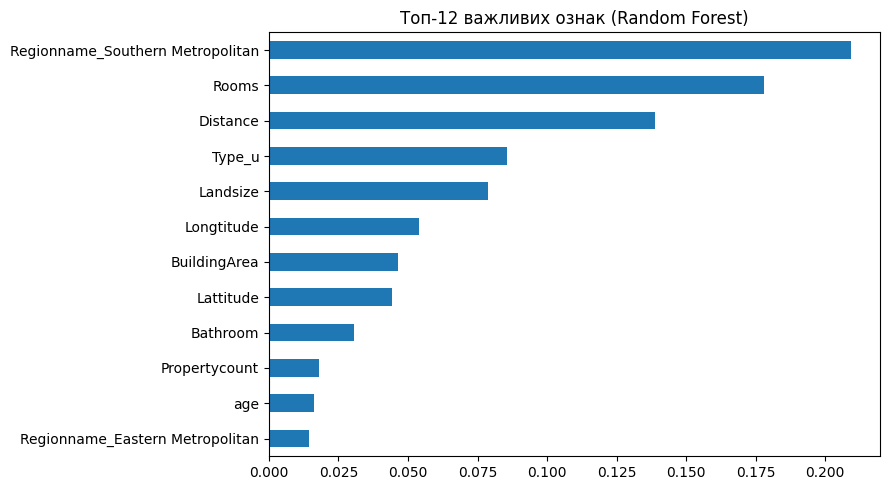

In [14]:
# КРОК 7. МОДЕЛЬ І ПРОГНОЗ
# ----------------------------------------------------------
def evaluate(model, name):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2   = r2_score(y_test, pred)
    print(f"\n{name}:")
    print(f"  MAE  = {mae:>12,.0f} AUD")
    print(f"  RMSE = {rmse:>12,.0f} AUD")
    print(f"  R²   = {r2:.3f}")
    return pipe

dummy = evaluate(DummyRegressor(strategy="mean"),   "Базова лінія (середнє)")
lr    = evaluate(LinearRegression(),                "Лінійна регресія")
rf    = evaluate(RandomForestRegressor(
                    n_estimators=100, random_state=RANDOM_STATE), "Випадковий ліс")

# Прогноз для конкретного прикладу
idx       = 0
pred_one  = rf.predict(X_test.iloc[[idx]])[0]
true_one  = y_test.iloc[idx]
print(f"\nПрогноз:     {pred_one:>12,.0f} AUD")
print(f"Справжня:    {true_one:>12,.0f} AUD")
print(f"Похибка:     {abs(pred_one - true_one):>12,.0f} AUD")

# Важливість ознак (топ-10)
ohe_names     = rf.named_steps["prep"].named_transformers_["cat"] \
                   .named_steps["ohe"].get_feature_names_out(cat_cols)
feature_names = num_cols + list(ohe_names)
importances   = (pd.Series(rf.named_steps["model"].feature_importances_,
                            index=feature_names)
                   .sort_values(ascending=False))
print("\nТоп-10 важливих ознак:")
print(importances.head(10).round(4))

importances.head(12).sort_values().plot(kind="barh", figsize=(9, 5),
    title="Топ-12 важливих ознак (Random Forest)")
plt.tight_layout(); plt.show()